In this computational experiment we use only a two-dimensional Lennard-Jones particle system. The molecular-dynamics machinery is provided in `lj_simulation.py`; your job is to choose parameters, run experiments, examine observations, and connect microscopic motion to macroscopic probability statements.

The microcanonical ensemble describes systems with fixed **N**, **V**, and **E**. 

This notebook uses reduced Lennard-Jones units: `epsilon = sigma = m = k_B = 1`. The box is two-dimensional and periodic. The potential is truncated and shifted at `rcut = 2.5`. Production dynamics use velocity-Verlet integration in the NVE ensemble, with no thermostat.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from lj_simulation import LJSystem, observation_count, make_equal_energy_replicas

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(2026)

# Student controls: edit these values and rerun the relevant cells.
N = 36
rho = 0.60
temperature = 1.00
dt = 0.002
seed = 7
production_steps = 4000
sample_interval = 4
window_fraction = 0.50  # fraction of the box side; area fraction is window_fraction**2

def window_counts(positions, box_length, fraction=window_fraction):
    return np.array([observation_count(frame, box_length, fraction) for frame in positions])

def discrete_pmf(values):
    support, frequencies = np.unique(values, return_counts=True)
    return support, frequencies / frequencies.sum()

def plot_pmf(support, probabilities, label, ax=None):
    ax = ax or plt.gca()
    ax.stem(support, probabilities, linefmt='C0-', markerfmt='C0o', basefmt=' ', label=label)
    ax.set_xlabel('n: particles in observation window')
    ax.set_ylabel('probability')
    ax.legend()
    return ax

## Part 1 — Run one microcanonical trajectory

Initialize one system and run NVE dynamics. The initial velocities are rescaled once to set a convenient starting kinetic energy. After production begins, no thermostat is applied.

In [16]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

system = LJSystem(N=N, rho=rho, temperature=temperature, dt=dt, seed=seed)
trajectory = system.run(production_steps, sample_interval=sample_interval, store_positions=True)

positions = trajectory["positions"]
time = trajectory["time"]
kinetic = trajectory["kinetic"]
potential = trajectory["potential"]
total = trajectory["total"]

# Use every frame, or increase this to 2 or 4 for a smaller animation
frame_stride = 1
frame_indices = np.arange(0, len(time), frame_stride)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Particle animation
scatter = axes[0].scatter(
    positions[0][:, 0],
    positions[0][:, 1],
    s=42
)

axes[0].set(
    xlim=(0, system.box_length),
    ylim=(0, system.box_length),
    aspect="equal",
    xlabel="x",
    ylabel="y"
)

# Energy curves
axes[1].plot(time, kinetic, label="K(t)")
axes[1].plot(time, potential, label="U(t)")
axes[1].plot(time, total, label="E(t) = K + U", lw=2)

energy_cursor = axes[1].axvline(
    time[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

kinetic_marker, = axes[1].plot(
    [time[0]], [kinetic[0]], "o", color="C0"
)
potential_marker, = axes[1].plot(
    [time[0]], [potential[0]], "o", color="C1"
)
total_marker, = axes[1].plot(
    [time[0]], [total[0]], "o", color="C2"
)

axes[1].set(
    xlabel="time",
    ylabel="energy",
    title="Energy exchange in NVE dynamics"
)
axes[1].legend()

def initialize():
    scatter.set_offsets(positions[0])
    energy_cursor.set_xdata([time[0], time[0]])

    kinetic_marker.set_data([time[0]], [kinetic[0]])
    potential_marker.set_data([time[0]], [potential[0]])
    total_marker.set_data([time[0]], [total[0]])

    axes[0].set_title(f"t = {time[0]:.2f}")
    return (
        scatter,
        energy_cursor,
        kinetic_marker,
        potential_marker,
        total_marker,
    )

def update(frame_number):
    scatter.set_offsets(positions[frame_number])
    energy_cursor.set_xdata([
        time[frame_number],
        time[frame_number]
    ])

    kinetic_marker.set_data(
        [time[frame_number]],
        [kinetic[frame_number]]
    )
    potential_marker.set_data(
        [time[frame_number]],
        [potential[frame_number]]
    )
    total_marker.set_data(
        [time[frame_number]],
        [total[frame_number]]
    )

    axes[0].set_title(f"t = {time[frame_number]:.2f}")

    return (
        scatter,
        energy_cursor,
        kinetic_marker,
        potential_marker,
        total_marker,
    )

# Keep the full-resolution data for plotting, but use fewer frames for animation
max_animation_frames = 200

frame_indices = np.linspace(
    0,
    len(time) - 1,
    min(max_animation_frames, len(time)),
    dtype=int
)

animation = FuncAnimation(
    fig,
    update,
    frames=frame_indices,
    init_func=initialize,
    interval=50,
    blit=True,
    repeat=True,
    repeat_delay=1000
)

plt.close(fig)

display(HTML(animation.to_jshtml()))

**Think about it.**

1. If this is a microcanonical simulation, which quantities are constrained?
2. Why can kinetic and potential energy fluctuate even though total energy is fixed?
3. What evidence shows that the numerical simulation approximately conserves energy?
4. Does “fixed E” mean that every observable is fixed?

## Part 2 — An observation window

Draw a centered square observation window inside the periodic box. Let `n(t)` be the number of particles inside it. The total particle number is fixed, but the local count need not be.

window area fraction = 0.250; mean n = 8.993; range = 6 to 12


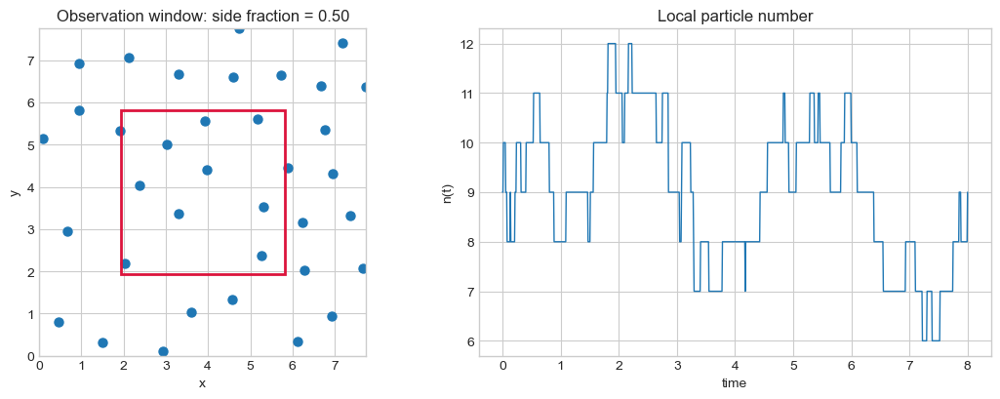

In [3]:
def plot_window(fraction=window_fraction):
    frame = trajectory['positions'][-1]
    half_width = 0.5 * fraction * system.box_length
    left = 0.5 * system.box_length - half_width
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    axes[0].scatter(frame[:, 0], frame[:, 1], s=42)
    axes[0].add_patch(plt.Rectangle((left, left), 2 * half_width, 2 * half_width,
                                  fill=False, color='crimson', lw=2))
    axes[0].set(xlim=(0, system.box_length), ylim=(0, system.box_length), aspect='equal',
                xlabel='x', ylabel='y', title=f'Observation window: side fraction = {fraction:.2f}')
    n_values = window_counts(trajectory['positions'], system.box_length, fraction)
    axes[1].plot(trajectory['time'], n_values, lw=1)
    axes[1].set(xlabel='time', ylabel='n(t)', title='Local particle number')
    plt.tight_layout()
    return n_values

n_values = plot_window()
print(f'window area fraction = {window_fraction**2:.3f}; mean n = {n_values.mean():.3f}; range = {n_values.min()} to {n_values.max()}')

In [4]:
# Optional interactive exploration. If widgets are unavailable, use the variable above.
try:
    import ipywidgets as widgets
    widgets.interact(plot_window, fraction=widgets.FloatSlider(min=0.20, max=0.90, step=0.05, value=window_fraction))
except Exception as error:
    print('Interactive slider unavailable; change window_fraction and rerun the previous cell.')
    print(error)

interactive(children=(FloatSlider(value=0.5, description='fraction', max=0.9, min=0.2, step=0.05), Output()), …

**Think about it.**

1. Why does `n(t)` fluctuate even though `N` is fixed?
2. What values of `n` occur most frequently?
3. Does `n(t)` ever stay at its average value for long?
4. What happens to the magnitude of fluctuations when the observation window becomes larger?

## Part 3 — Time averages

Estimate the time average with the discrete sample mean and plot the running average. The instantaneous observable can fluctuate strongly while its average becomes progressively more stable.

<n>_time = 8.99301


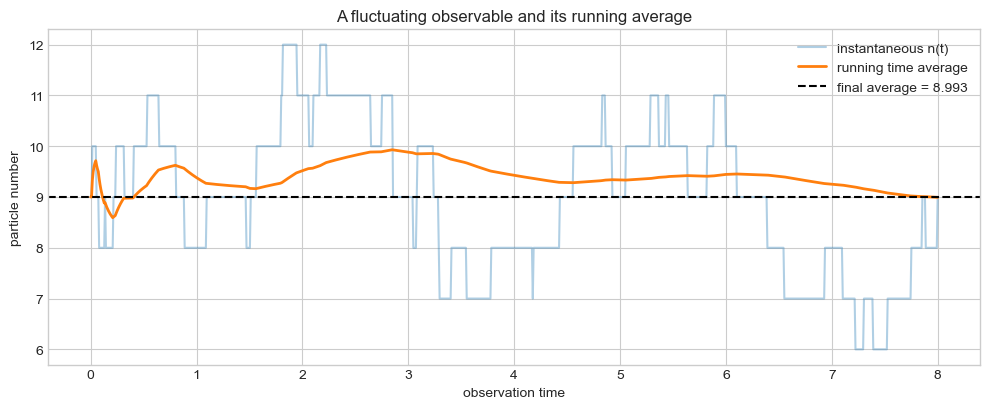

In [5]:
n_time = window_counts(trajectory['positions'], system.box_length, window_fraction)
n_time_average = n_time.mean()
running_average = np.cumsum(n_time) / np.arange(1, len(n_time) + 1)

plt.figure(figsize=(10, 4.2))
plt.plot(trajectory['time'], n_time, alpha=0.35, label='instantaneous n(t)')
plt.plot(trajectory['time'], running_average, lw=2, label='running time average')
plt.axhline(n_time_average, color='black', ls='--', label=f'final average = {n_time_average:.3f}')
plt.xlabel('observation time')
plt.ylabel('particle number')
plt.title('A fluctuating observable and its running average')
plt.legend()
plt.tight_layout()
print(f'<n>_time = {n_time_average:.5f}')

**Think about it.** Does the running average converge? How much trajectory is needed before it is reasonably stable? If you restart with a different seed, do you get exactly the same finite-time average? What changes when the trajectory is longer?

## Part 4 — A probability distribution from one trajectory

Use the same trajectory to estimate `P(n)`, the probability of observing each particle count. This is a time-based estimate of a distribution over macroscopic observations.

sum_n P_time(n) = 1.000000
<n>_P = sum_n n P_time(n) = 8.99301
<n>_time = 8.99301; difference = +0.000e+00


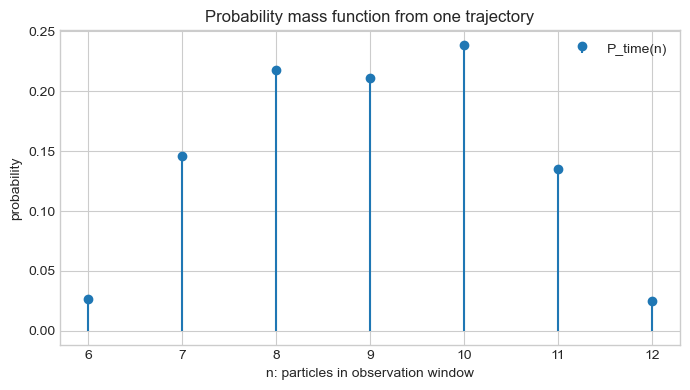

In [6]:
support_time, p_time = discrete_pmf(n_time)
n_from_p = np.sum(support_time * p_time)
fig, ax = plt.subplots(figsize=(7, 4))
plot_pmf(support_time, p_time, 'P_time(n)', ax=ax)
ax.set_title('Probability mass function from one trajectory')
plt.tight_layout()
print(f'sum_n P_time(n) = {p_time.sum():.6f}')
print(f'<n>_P = sum_n n P_time(n) = {n_from_p:.5f}')
print(f'<n>_time = {n_time_average:.5f}; difference = {n_from_p - n_time_average:+.3e}')

The most probable value of `n` need not be the mean. Equal a-priori probability refers to accessible **microstates**, not to macroscopic labels. Many different microscopic configurations can have the same value of `n`; a value with more compatible microstates can therefore have greater probability.

**Think about it.** Why is `P(n)` not uniform if accessible microstates are equally probable? What does `P(n)` count or represent?

## Part 5 — Build an actual ensemble

Now create independent replicas with the same `N`, `V`, and total energy. Their positions and velocity directions differ. The helper function rescales each replica's initial velocities so that its starting `K + U` equals the reference energy within floating-point tolerance. We then evolve each replica with NVE dynamics and observe `n` once.

In [7]:
M = 40  # increase this for a smoother ensemble distribution
replicas = make_equal_energy_replicas(system, count=M, seed=100)
initial_replica_energies = np.array([replica.total_energy() for replica in replicas])
target_energy = system.total_energy()
print(f'reference target energy = {target_energy:.8f}')
print(f'max initial replica energy mismatch = {np.max(np.abs(initial_replica_energies - target_energy)):.3e}')

replica_n = []
final_replica_energies = []
for replica in replicas:
    short_run = replica.run(300, sample_interval=300, store_positions=True)
    replica_n.append(observation_count(short_run['positions'][-1], replica.box_length, window_fraction))
    final_replica_energies.append(short_run['total'][-1])
replica_n = np.asarray(replica_n)
final_replica_energies = np.asarray(final_replica_energies)
ensemble_average = replica_n.mean()
print(f'<n>_ensemble = {ensemble_average:.5f}')
print(f'max final energy mismatch = {np.max(np.abs(final_replica_energies - target_energy)):.3e}')

reference target energy = -19.26004183
max initial replica energy mismatch = 1.421e-14
<n>_ensemble = 9.05000
max final energy mismatch = 4.637e-03


One system + many times -> time average
Many systems + one observation -> ensemble average


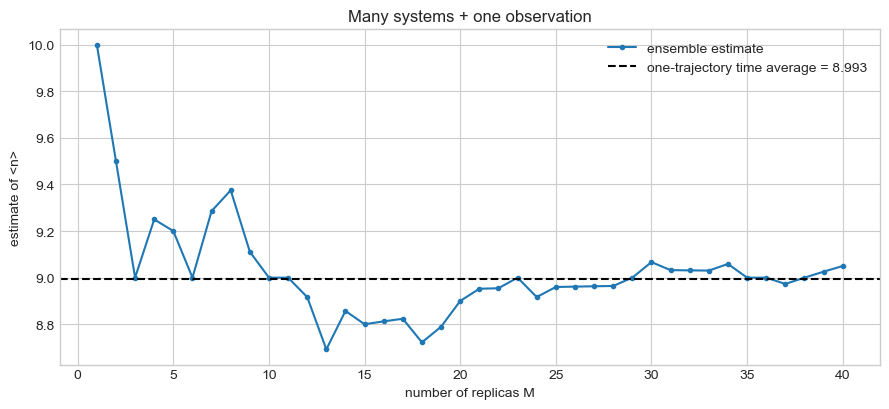

In [8]:
replica_numbers = np.arange(1, M + 1)
cumulative_ensemble_average = np.cumsum(replica_n) / replica_numbers
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(replica_numbers, cumulative_ensemble_average, marker='o', ms=3, label='ensemble estimate')
ax.axhline(n_time_average, color='black', ls='--', label=f'one-trajectory time average = {n_time_average:.3f}')
ax.set(xlabel='number of replicas M', ylabel='estimate of <n>', title='Many systems + one observation')
ax.legend()
plt.tight_layout()
print('One system + many times -> time average')
print('Many systems + one observation -> ensemble average')


**Think about it.** Do the two averages approach the same value? How do the estimates change with `M` and with trajectory length? Why might an ensemble be computationally useful even if nature gives us only one physical system? Which comparison motivates the ergodic hypothesis?

## Part 6 — Time ensemble versus replica ensemble

Agreement of one mean is a weak test. Compare the whole distributions `P_time(n)` and `P_ensemble(n)`, including their means, variances, and overall shapes.

time:     mean = 8.9930, variance = 2.0469
ensemble: mean = 9.0500, variance = 1.4975
sum P_time = 1.000000; sum P_ensemble = 1.000000


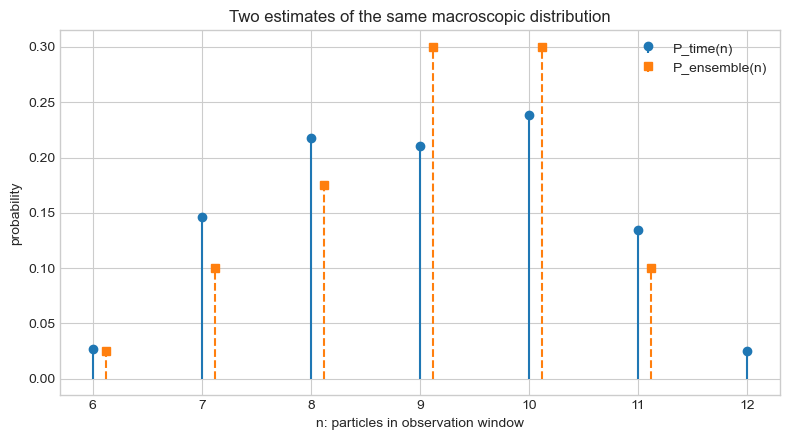

In [9]:
support_ensemble, p_ensemble = discrete_pmf(replica_n)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.stem(support_time, p_time, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='P_time(n)')
ax.stem(support_ensemble + 0.12, p_ensemble, linefmt='C1--', markerfmt='C1s', basefmt=' ', label='P_ensemble(n)')
ax.set(xlabel='n: particles in observation window', ylabel='probability', title='Two estimates of the same macroscopic distribution')
ax.legend()
plt.tight_layout()
print(f'time:     mean = {n_time.mean():.4f}, variance = {n_time.var():.4f}')
print(f'ensemble: mean = {replica_n.mean():.4f}, variance = {replica_n.var():.4f}')
print(f'sum P_time = {p_time.sum():.6f}; sum P_ensemble = {p_ensemble.sum():.6f}')

**Think about it.** Do the distributions agree? Is agreement of the mean sufficient to claim ensemble equivalence? Which comparison is stronger: one mean, or mean + variance + overall shape? How do finite sampling errors appear?

## Part 7 — System size and fluctuations

Repeat the observation-window experiment for several system sizes at approximately fixed density. The window occupies the same fraction of the box side in every case. This is a qualitative exploration; do not assume an exact scaling law from a short trajectory.

,N,mean n,variance(n),relative fluctuation
0,16,3.960133,0.244258,0.124800
1,36,9.385382,1.359786,0.124246
2,64,16.996678,1.318926,0.067569


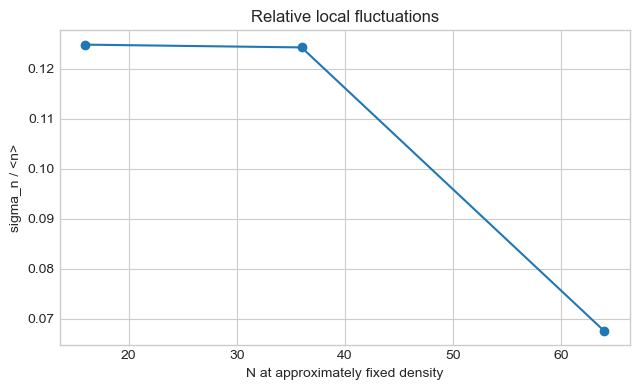

In [10]:
size_results = []
for size, size_seed in zip([16, 36, 64], [16, 36, 64]):
    size_system = LJSystem(N=size, rho=rho, temperature=temperature, dt=dt, seed=size_seed)
    size_trajectory = size_system.run(1200, sample_interval=4, store_positions=True)
    size_n = window_counts(size_trajectory['positions'], size_system.box_length, window_fraction)
    mean_n = size_n.mean()
    size_results.append({
        'N': size,
        'mean n': mean_n,
        'variance(n)': size_n.var(),
        'relative fluctuation': size_n.std() / mean_n,
    })
size_table = pd.DataFrame(size_results)
display(size_table)

plt.figure(figsize=(6.5, 4))
plt.plot(size_table['N'], size_table['relative fluctuation'], 'o-')
plt.xlabel('N at approximately fixed density')
plt.ylabel('sigma_n / <n>')
plt.title('Relative local fluctuations')
plt.tight_layout()

**Think about it.** Do absolute fluctuations disappear as the system becomes larger? What happens to relative fluctuations? Why can macroscopic quantities appear nearly deterministic even though microscopic quantities fluctuate?